# Project 3: Music

In [536]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error,root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

In [538]:
df = pd.read_csv('song_data.csv')

In [540]:
df

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,Boulevard of Broken Dreams,73,262333,0.005520,0.496,0.682,0.000029,8,0.0589,-4.095,1,0.0294,167.060,4,0.474
1,In The End,66,216933,0.010300,0.542,0.853,0.000000,3,0.1080,-6.407,0,0.0498,105.256,4,0.370
2,Seven Nation Army,76,231733,0.008170,0.737,0.463,0.447000,0,0.2550,-7.828,1,0.0792,123.881,4,0.324
3,By The Way,74,216933,0.026400,0.451,0.970,0.003550,0,0.1020,-4.938,1,0.1070,122.444,4,0.198
4,How You Remind Me,56,223826,0.000954,0.447,0.766,0.000000,10,0.1130,-5.065,1,0.0313,172.011,4,0.574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18830,Let It Breathe,60,159645,0.893000,0.500,0.151,0.000065,11,0.1110,-16.107,1,0.0348,113.969,4,0.300
18831,Answers,60,205666,0.765000,0.495,0.161,0.000001,11,0.1050,-14.078,0,0.0301,94.286,4,0.265
18832,Sudden Love (Acoustic),23,182211,0.847000,0.719,0.325,0.000000,0,0.1250,-12.222,1,0.0355,130.534,4,0.286
18833,Gentle on My Mind,55,352280,0.945000,0.488,0.326,0.015700,3,0.1190,-12.020,1,0.0328,106.063,4,0.323


In [542]:
df.shape

(18835, 15)

In [544]:
df = df.dropna(axis=1)

In [546]:
df.shape

(18835, 15)

Im going to mainly model based on song durration, tempo, and danceability. I wish I had release year, however it seems like this data set does not include this data, so we shall forgo it for now

for now let's see if there's any relation using a correlation matrix (excluding song titles)

In [549]:
df = df.drop('song_name',axis =1)
corr = df.corr()

<Axes: >

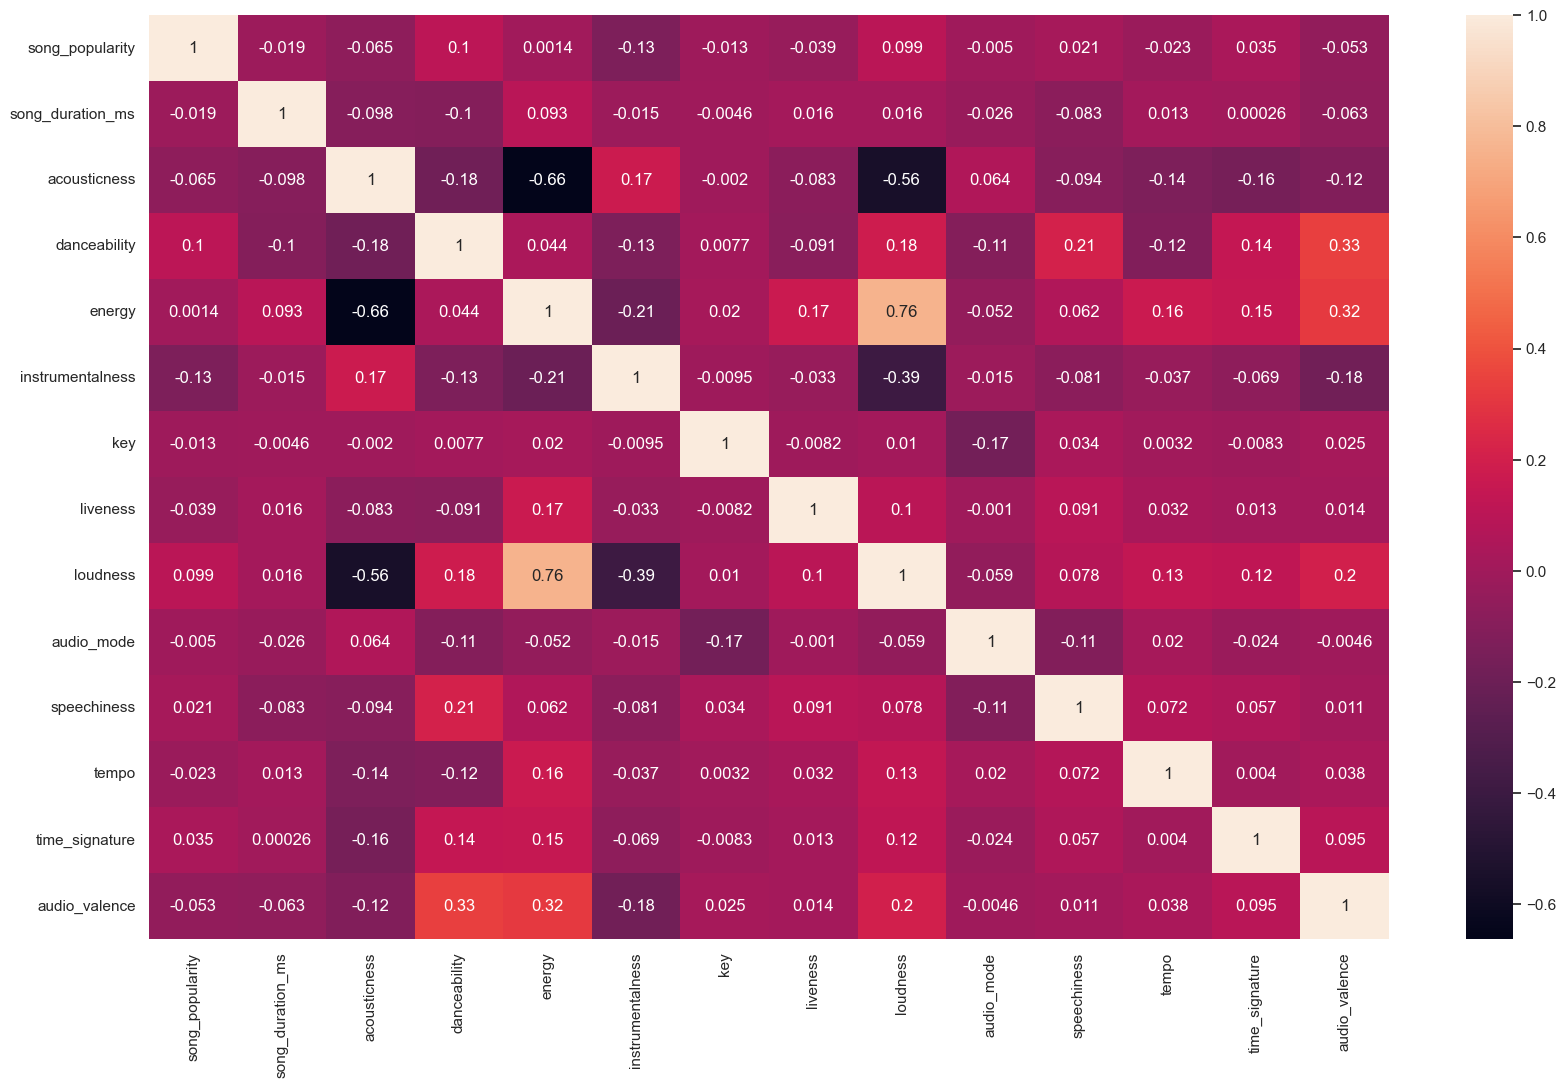

In [551]:
sns.set(rc={'figure.figsize':(20, 12)}) 
sns.heatmap(corr, annot=True)

It seems the strongest relationship here is energy with audio at a 0.76. Theres also the correlation between loudness & accousticness and energy & accousticness

<Axes: xlabel='energy', ylabel='loudness'>

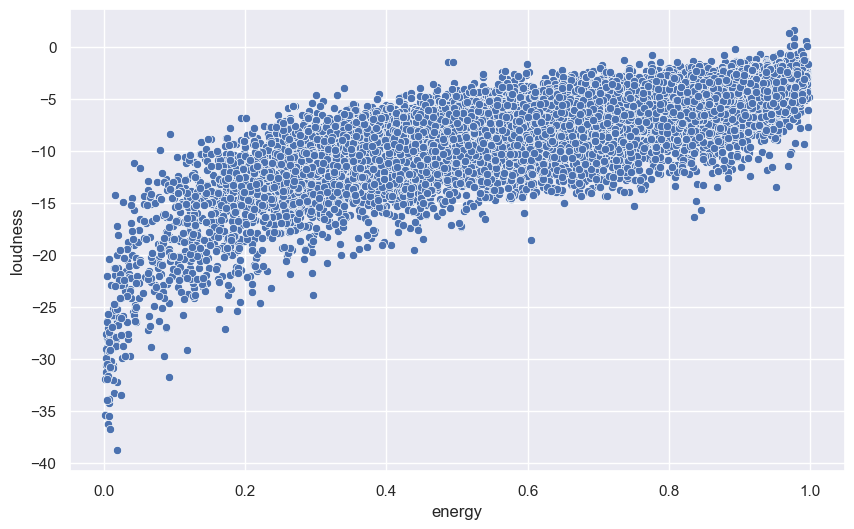

In [553]:
sns.set(rc={'figure.figsize':(10, 6)}) 
sns.scatterplot(x='energy', y='loudness', data=df)

<Axes: xlabel='energy', ylabel='acousticness'>

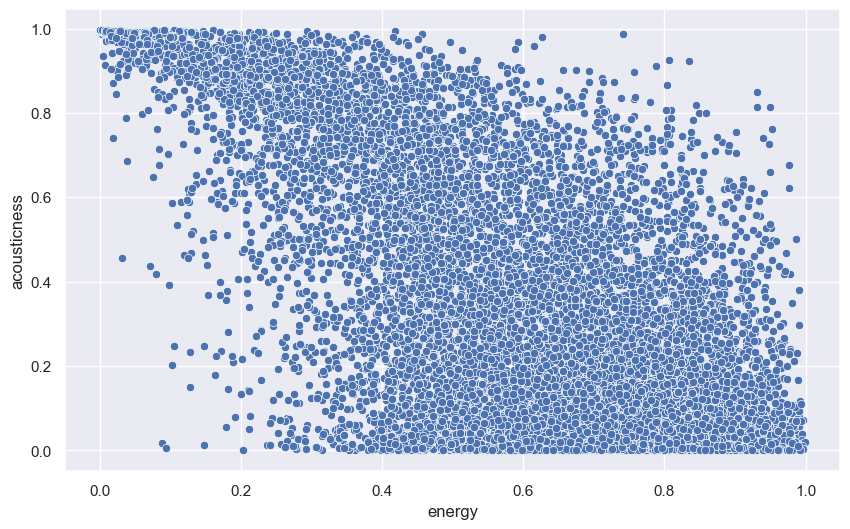

In [555]:
sns.set(rc={'figure.figsize':(10, 6)}) 
sns.scatterplot(x='energy', y='acousticness', data=df)

<Axes: xlabel='loudness', ylabel='acousticness'>

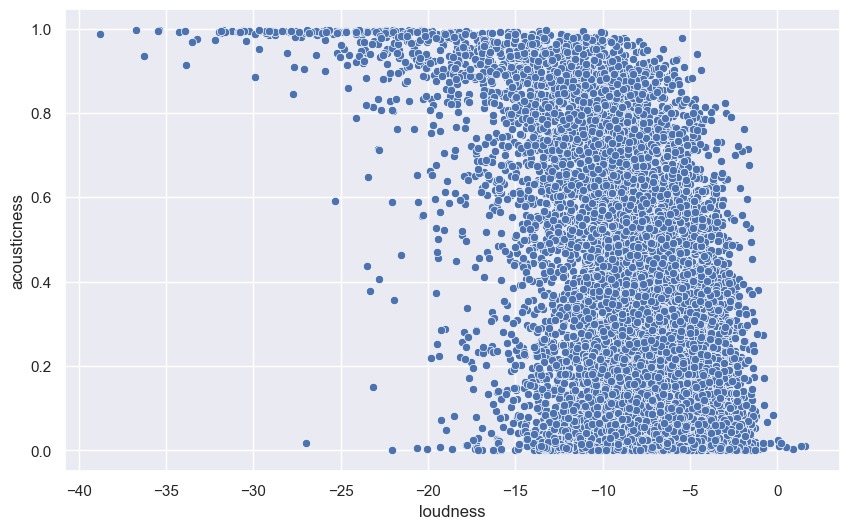

In [557]:
sns.scatterplot(x='loudness', y='acousticness', data=df)

For my first model I'll use the relationship between energy and loudness 

# Experiment 1 

In [562]:
y = df['loudness']
X = df[['energy']]


In [564]:
from sklearn.model_selection import train_test_split

In [566]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [568]:
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (13184, 1)
X_test (5651, 1)
y_train (13184,)
y_test (5651,)


In [570]:
regr = linear_model.LinearRegression()

regr.fit(X_train, y_train)

LinearRegression()

In [572]:
y_pred1 = regr.predict(X_test)

Coefficients: 
 [13.46329636]
Mean squared error: 6.14
Root Mean squared error: 2.48
Coefficient of determination: 0.59


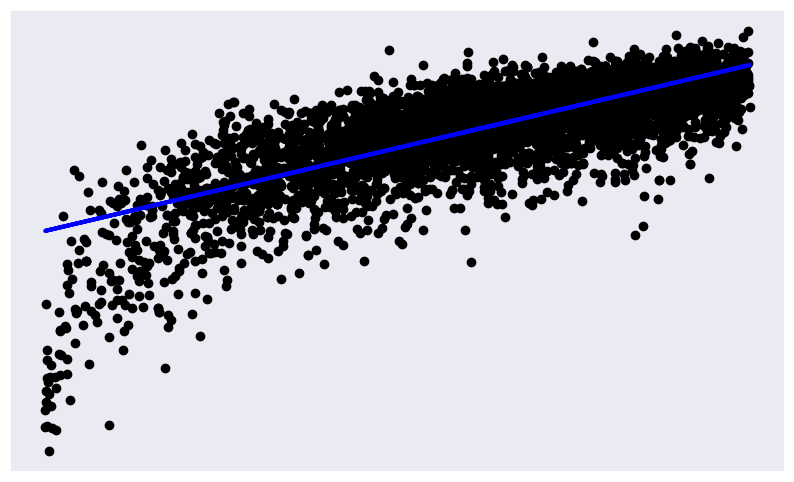

In [574]:
print('Coefficients: \n', regr.coef_)
print('Mean squared error: %.2f'% mean_squared_error(y_test, y_pred1))
print('Root Mean squared error: %.2f'% root_mean_squared_error(y_test, y_pred1))
print('Coefficient of determination: %.2f'  % r2_score(y_test, y_pred1))
plt.scatter(X_test, y_test,  color='black')
plt.plot(X_test, y_pred1, color='blue', linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

In [576]:
X2 = sm.add_constant(X)

In [578]:
est = sm.OLS(y, X2)

In [580]:
est2 = est.fit()

In [582]:
est2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               loudness   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.571
Method:                 Least Squares   F-statistic:                 2.505e+04
Date:                Mon, 31 Mar 2025   Prob (F-statistic):               0.00
Time:                        21:08:11   Log-Likelihood:                -44042.
No. Observations:               18835   AIC:                         8.809e+04
Df Residuals:                   18833   BIC:                         8.810e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -16.1598      0.058   -278.599      0.000     -16.273     -16.046
energy        13.5076      0.085    158.261      0.000      13.340      13.675
==============================================================================
Omnibus:                     5442.816   Durbin-Watson:                   1.261
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            25971.752
Skew:                          -1.328   Prob(JB):                         0.00
Kurtosis:                       8.103   Cond. No.                         6.68
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Experiment 2: Energy & Acousticness

In [585]:
y = df[['acousticness']]
X = df[['energy']]

In [587]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [589]:
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (15068, 1)
X_test (3767, 1)
y_train (15068, 1)
y_test (3767, 1)


In [591]:
regr = linear_model.LinearRegression()

regr.fit(X_train, y_train)

LinearRegression()

In [593]:
y_pred2 = regr.predict(X_test)

Coefficients: 
 [[-0.89510105]]
Mean squared error: 0.05
Root Mean squared error: 0.22
Coefficient of determination: 0.43


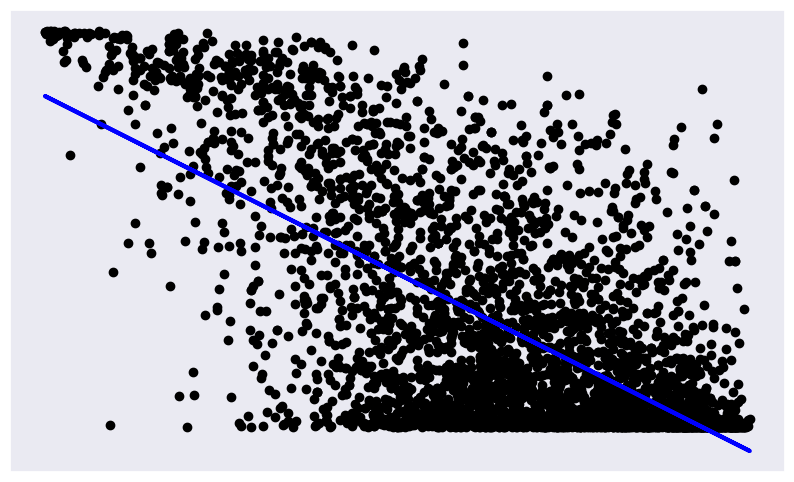

In [595]:
print('Coefficients: \n', regr.coef_)
print('Mean squared error: %.2f'% mean_squared_error(y_test, y_pred2))
print('Root Mean squared error: %.2f'% root_mean_squared_error(y_test, y_pred2))
print('Coefficient of determination: %.2f'  % r2_score(y_test, y_pred2))
plt.scatter(X_test, y_test,  color='black')
plt.plot(X_test, y_pred2, color='blue', linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

In [597]:
X2 = sm.add_constant(X)

In [599]:
est = sm.OLS(y, X2)

In [601]:
est2 = est.fit()

In [603]:
est2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           acousticness   R-squared:                       0.439
Model:                            OLS   Adj. R-squared:                  0.439
Method:                 Least Squares   F-statistic:                 1.474e+04
Date:                Mon, 31 Mar 2025   Prob (F-statistic):               0.00
Time:                        21:08:15   Log-Likelihood:                 2118.7
No. Observations:               18835   AIC:                            -4233.
Df Residuals:                   18833   BIC:                            -4218.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8349      0.005    166.930      0.000       0.825       0.845
energy        -0.8936      0.007   -121.420      0.000      -0.908      -0.879
==============================================================================
Omnibus:                      429.815   Durbin-Watson:                   1.528
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              459.365
Skew:                           0.382   Prob(JB):                    1.78e-100
Kurtosis:                       3.051   Cond. No.                         6.68
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Experiment 3: Loudness VS Acousticness 

In [606]:
y = df[['acousticness']]
X = df[['loudness']]

In [608]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [610]:
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (15068, 1)
X_test (3767, 1)
y_train (15068, 1)
y_test (3767, 1)


In [612]:
regr = linear_model.LinearRegression()

regr.fit(X_train, y_train)

LinearRegression()

In [614]:
y_pred2 = regr.predict(X_test)

Coefficients: 
 [[-0.04216571]]
Mean squared error: 0.06
Root Mean squared error: 0.24
Coefficient of determination: 0.30


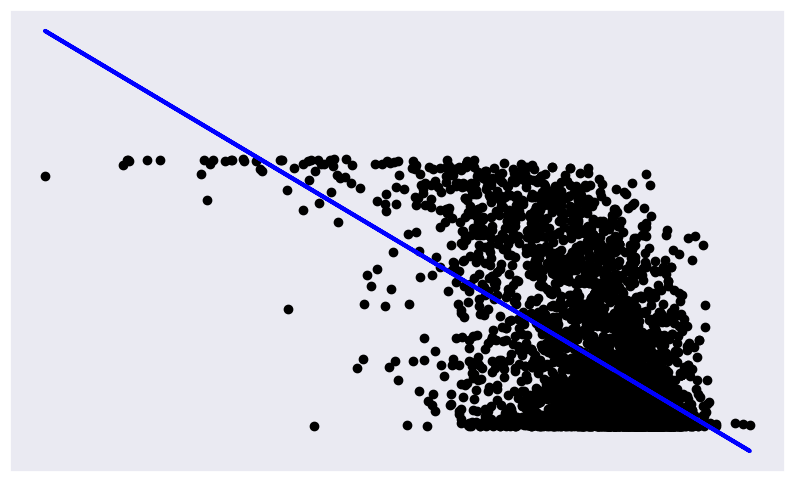

In [616]:
print('Coefficients: \n', regr.coef_)
print('Mean squared error: %.2f'% mean_squared_error(y_test, y_pred2))
print('Root Mean squared error: %.2f'% root_mean_squared_error(y_test, y_pred2))
print('Coefficient of determination: %.2f'  % r2_score(y_test, y_pred2))
plt.scatter(X_test, y_test,  color='black')
plt.plot(X_test, y_pred2, color='blue', linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

In [618]:
X2 = sm.add_constant(X)

In [620]:
est = sm.OLS(y, X2)

In [622]:
est2 = est.fit()

In [624]:
est2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           acousticness   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     8504.
Date:                Mon, 31 Mar 2025   Prob (F-statistic):               0.00
Time:                        21:08:18   Log-Likelihood:                 182.77
No. Observations:               18835   AIC:                            -361.5
Df Residuals:                   18833   BIC:                            -345.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0548      0.004    -14.336      0.000      -0.062      -0.047
loudness      -0.0421      0.000    -92.217      0.000      -0.043      -0.041
==============================================================================
Omnibus:                     1093.107   Durbin-Watson:                   1.401
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1295.568
Skew:                           0.642   Prob(JB):                    4.69e-282
Kurtosis:                       2.975   Cond. No.                         18.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""